BIOGrid

In [1]:
import pandas as pd
import networkx as nx
from pathlib import Path


biogrid_file = "BIOGRID-GENE-113010-5.0.261.tab3.txt"

biogrid = pd.read_csv(
    biogrid_file,
    sep="\t",
    low_memory=False
)

print("BioGRID shape:", biogrid.shape)
print(biogrid.columns.tolist())

BioGRID shape: (6121, 37)
['#BioGRID Interaction ID', 'Entrez Gene Interactor A', 'Entrez Gene Interactor B', 'BioGRID ID Interactor A', 'BioGRID ID Interactor B', 'Systematic Name Interactor A', 'Systematic Name Interactor B', 'Official Symbol Interactor A', 'Official Symbol Interactor B', 'Synonyms Interactor A', 'Synonyms Interactor B', 'Experimental System', 'Experimental System Type', 'Author', 'Publication Source', 'Organism ID Interactor A', 'Organism ID Interactor B', 'Throughput', 'Score', 'Modification', 'Qualifications', 'Tags', 'Source Database', 'SWISS-PROT Accessions Interactor A', 'TREMBL Accessions Interactor A', 'REFSEQ Accessions Interactor A', 'SWISS-PROT Accessions Interactor B', 'TREMBL Accessions Interactor B', 'REFSEQ Accessions Interactor B', 'Ontology Term IDs', 'Ontology Term Names', 'Ontology Term Categories', 'Ontology Term Qualifier IDs', 'Ontology Term Qualifier Names', 'Ontology Term Types', 'Organism Name Interactor A', 'Organism Name Interactor B']


оставляем только homo sapiens

In [2]:
bio = biogrid[
    (biogrid["Experimental System Type"].str.lower() == "physical") &
    (biogrid["Organism ID Interactor A"] == 9606) &
    (biogrid["Organism ID Interactor B"] == 9606)
].copy()

bio = bio[
    [
        "Official Symbol Interactor A",
        "Official Symbol Interactor B",
        "Experimental System"
    ]
]

bio.columns = ["protein1", "protein2", "evidence"]

print("Physical BioGRID interactions:", len(bio))
print(bio.head())

Physical BioGRID interactions: 5598
  protein1 protein2              evidence
0     TP53     WWOX            Two-hybrid
1     TP53   CDC14A            Two-hybrid
2     TP53  MAGEB18            Two-hybrid
3     DVL2     TP53            Two-hybrid
4     TP53  TP53BP1  Co-crystal Structure


In [3]:
G_bio = nx.from_pandas_edgelist(
    bio,
    source="protein1",
    target="protein2",
    edge_attr="evidence"
)

print("BioGRID nodes:", G_bio.number_of_nodes())
print("BioGRID edges:", G_bio.number_of_edges())

BioGRID nodes: 2203
BioGRID edges: 2203


String

In [6]:
info_file = "9606.protein.info.v12.0.txt"
links_file = "9606.protein.physical.links.detailed.v12.0.txt"

string_info = pd.read_csv(
    info_file,
    sep="\t",
    low_memory=False
)

print(string_info.head())
print(string_info.columns)

     #string_protein_id preferred_name  protein_size  \
0  9606.ENSP00000000233           ARF5           180   
1  9606.ENSP00000000412           M6PR           277   
2  9606.ENSP00000001008          FKBP4           459   
3  9606.ENSP00000001146        CYP26B1           512   
4  9606.ENSP00000002125        NDUFAF7           441   

                                          annotation  
0  ADP-ribosylation factor 5; GTP-binding protein...  
1  Cation-dependent mannose-6-phosphate receptor;...  
2  Peptidyl-prolyl cis-trans isomerase FKBP4, N-t...  
3  Cytochrome P450 26B1; Involved in the metaboli...  
4  Protein arginine methyltransferase NDUFAF7, mi...  
Index(['#string_protein_id', 'preferred_name', 'protein_size', 'annotation'], dtype='str')


In [7]:
tp53_row = string_info[
    string_info["preferred_name"] == "TP53"
]

print(tp53_row)

        #string_protein_id preferred_name  protein_size  \
3183  9606.ENSP00000269305           TP53           393   

                                             annotation  
3183  Cellular tumor antigen p53; Acts as a tumor su...  


String iD

In [8]:
tp53_id = tp53_row["#string_protein_id"].iloc[0]

print("TP53 STRING ID:", tp53_id)

TP53 STRING ID: 9606.ENSP00000269305


physical network

In [9]:
string_links = pd.read_csv(
    links_file,
    sep=r"\s+",
    low_memory=False
)

print(string_links.shape)
print(string_links.columns)
print(string_links.head())

(1477610, 6)
Index(['protein1', 'protein2', 'experimental', 'database', 'textmining',
       'combined_score'],
      dtype='str')
               protein1              protein2  experimental  database  \
0  9606.ENSP00000000233  9606.ENSP00000257770           312         0   
1  9606.ENSP00000000233  9606.ENSP00000226004           162         0   
2  9606.ENSP00000000233  9606.ENSP00000434442             0       500   
3  9606.ENSP00000000233  9606.ENSP00000262455           531         0   
4  9606.ENSP00000000233  9606.ENSP00000303145             0       500   

   textmining  combined_score  
0           0             311  
1           0             161  
2           0             499  
3           0             531  
4           0             499  


взаимодействия только с TP53

In [10]:
string_tp53 = string_links[
    (string_links["protein1"] == tp53_id) |
    (string_links["protein2"] == tp53_id)
].copy()

print("STRING TP53 interactions:", len(string_tp53))
print(string_tp53.head())

STRING TP53 interactions: 4110
                  protein1              protein2  experimental  database  \
336   9606.ENSP00000001008  9606.ENSP00000269305           292         0   
836   9606.ENSP00000003302  9606.ENSP00000269305           465         0   
1245  9606.ENSP00000005260  9606.ENSP00000269305           292         0   
1500  9606.ENSP00000005340  9606.ENSP00000269305           266         0   
3499  9606.ENSP00000011619  9606.ENSP00000269305           465         0   

      textmining  combined_score  
336          101             336  
836           59             475  
1245           0             292  
1500           0             266  
3499           0             465  


In [11]:
id_to_name = dict(
    zip(
        string_info["#string_protein_id"],
        string_info["preferred_name"]
    )
)

string_tp53["gene1"] = string_tp53["protein1"].map(id_to_name)
string_tp53["gene2"] = string_tp53["protein2"].map(id_to_name)

print(
    string_tp53[
        ["gene1", "gene2", "combined_score"]
    ].head()
)

         gene1 gene2  combined_score
336      FKBP4  TP53             336
836      USP28  TP53             475
1245  BAIAP2L1  TP53             292
1500      DVL2  TP53             266
3499    RANBP9  TP53             465


In [12]:
G_string = nx.from_pandas_edgelist(
    string_tp53,
    source="gene1",
    target="gene2",
    edge_attr=True
)

print("STRING nodes:", G_string.number_of_nodes())
print("STRING edges:", G_string.number_of_edges())

STRING nodes: 2056
STRING edges: 2055


In [13]:
print("BioGRID nodes:", G_bio.number_of_nodes())
print("BioGRID edges:", G_bio.number_of_edges())

print("STRING nodes:", G_string.number_of_nodes())
print("STRING edges:", G_string.number_of_edges())

BioGRID nodes: 2203
BioGRID edges: 2203
STRING nodes: 2056
STRING edges: 2055


сравнение покрытий

In [14]:
bio_nodes = set(G_bio.nodes())
string_nodes = set(G_string.nodes())

common = bio_nodes & string_nodes
only_bio = bio_nodes - string_nodes
only_string = string_nodes - bio_nodes

print("BioGRID proteins:", len(bio_nodes))
print("STRING proteins:", len(string_nodes))
print("Common proteins:", len(common))
print("Only BioGRID:", len(only_bio))
print("Only STRING:", len(only_string))

print(
    "BioGRID overlap:",
    round(len(common) / len(bio_nodes) * 100, 2),
    "%"
)

print(
    "STRING overlap:",
    round(len(common) / len(string_nodes) * 100, 2),
    "%"
)

BioGRID proteins: 2203
STRING proteins: 2056
Common proteins: 1596
Only BioGRID: 607
Only STRING: 460
BioGRID overlap: 72.45 %
STRING overlap: 77.63 %


In [15]:
print("Only BioGRID:")
print(sorted(only_bio)[:20])

print("\nOnly STRING:")
print(sorted(only_string)[:20])

Only BioGRID:
['AARS', 'AASDH', 'AATK', 'ABCF1', 'ABCF2', 'ACADM', 'ACE2', 'ACO2', 'ACTG1', 'ACTR3', 'ADAR', 'ADH5', 'ADRBK1', 'AGBL2', 'AGPAT6', 'AHCY', 'AIFM1', 'AIP', 'ALB', 'ALDH18A1']

Only STRING:
['AARS1', 'ABL2', 'ABRAXAS2', 'ACSS2', 'ACTN2', 'ACTR10', 'ADCY2', 'AIG1', 'AKAP13', 'ANKRD11', 'APOE', 'AR', 'ARHGAP11A', 'ARMC1', 'ATAD3A', 'ATAD3B', 'ATF2', 'ATF7IP2', 'ATG7', 'ATP5F1A']


In [16]:
print(
    bio["evidence"]
    .value_counts()
    .head(15)
)

evidence
Affinity Capture-Western    1969
Affinity Capture-MS         1610
Reconstituted Complex        689
Proximity Label-MS           408
Biochemical Activity         385
Two-hybrid                   172
Co-localization              118
Protein-peptide               58
Co-fractionation              54
Co-crystal Structure          42
FRET                          34
Co-purification               18
PCA                           13
Far Western                   12
Affinity Capture-RNA           8
Name: count, dtype: int64


In [17]:
print(string_tp53.columns.tolist())

['protein1', 'protein2', 'experimental', 'database', 'textmining', 'combined_score', 'gene1', 'gene2']


In [18]:
evidence_cols = ["experimental", "database", "textmining"]

for col in evidence_cols:
    nonzero = (string_tp53[col] > 0).sum()
    print(f"{col}: {nonzero} interactions")

experimental: 3518 interactions
database: 144 interactions
textmining: 1430 interactions


Возьмем 50 сильнейших связей и связи между ними

In [24]:
# определяем партнера TP53 в каждой строке
string_tp53["partner"] = string_tp53.apply(
    lambda row: row["gene2"]
    if row["gene1"] == "TP53"
    else row["gene1"],
    axis=1
)

# для каждого партнера оставляем максимальный score
top50_partners = (
    string_tp53
    .groupby("partner", as_index=False)["combined_score"]
    .max()
    .sort_values("combined_score", ascending=False)
    .head(50)
)

top_genes = set(top50_partners["partner"])
top_genes.add("TP53")

print("Selected interactors:", len(top50_partners))
print("Total proteins:", len(top_genes))

Selected interactors: 50
Total proteins: 51


In [25]:
selected_ids = set(
    string_info.loc[
        string_info["preferred_name"].isin(top_genes),
        "#string_protein_id"
    ]
)

sub = string_links[
    string_links["protein1"].isin(selected_ids) &
    string_links["protein2"].isin(selected_ids)
].copy()

sub["gene1"] = sub["protein1"].map(id_to_name)
sub["gene2"] = sub["protein2"].map(id_to_name)

G = nx.from_pandas_edgelist(
    sub,
    source="gene1",
    target="gene2",
    edge_attr="combined_score"
)

degrees = dict(G.degree())

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", round(nx.density(G), 3))

print("\nTop hubs:")
for gene, degree in sorted(
    degrees.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]:
    print(f"{gene:10s} degree = {degree}")

Nodes: 51
Edges: 354
Density: 0.278

Top hubs:
TP53       degree = 50
MDM2       degree = 34
MYC        degree = 33
BRCA1      degree = 29
EP300      degree = 29
HSP90AA1   degree = 24
HSPA4      degree = 23
CREBBP     degree = 23
JUN        degree = 22
HDAC1      degree = 21


подграф

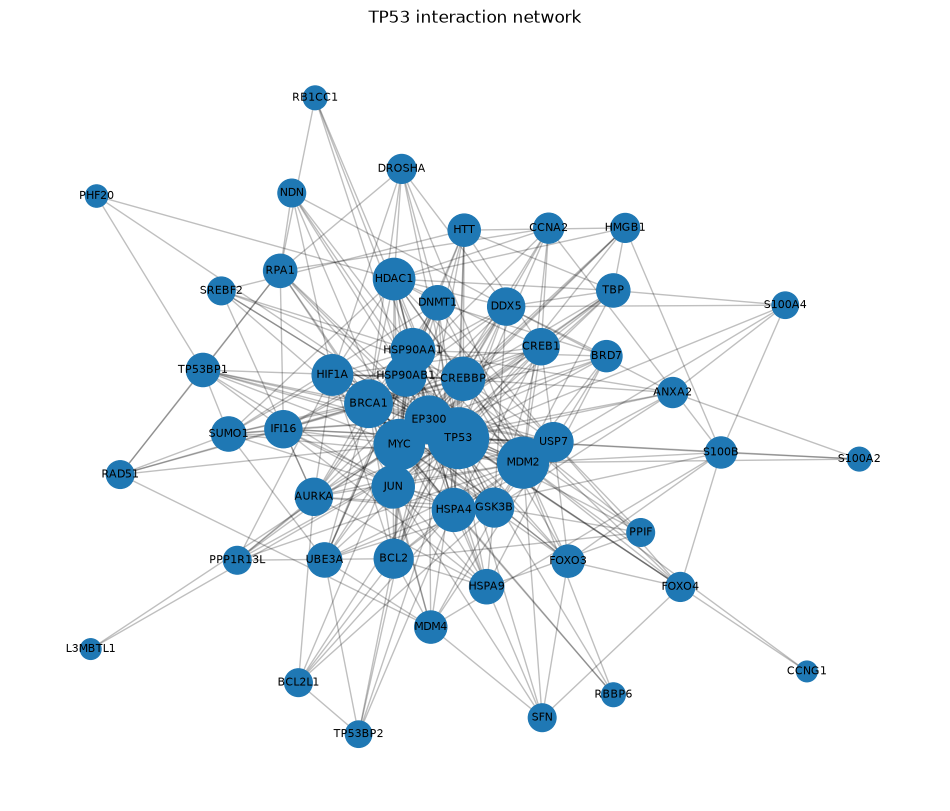

In [26]:
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42)

node_sizes = [
    150 + degrees[node] * 35
    for node in G.nodes()
]

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.25
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title("TP53 interaction network")
plt.axis("off")
plt.show()

распределение степеней

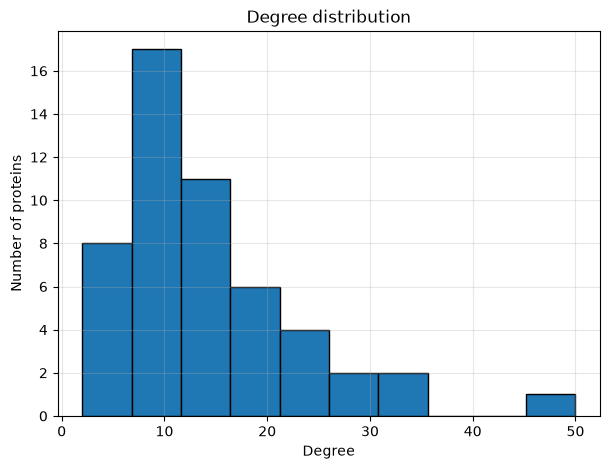

In [27]:
degree_values = list(degrees.values())

plt.figure(figsize=(7, 5))

plt.hist(
    degree_values,
    bins=10,
    edgecolor="black"
)

plt.xlabel("Degree")
plt.ylabel("Number of proteins")
plt.title("Degree distribution")

plt.grid(alpha=0.3)
plt.show()